# SciPy's quad function family

First, we need to import `numpy` for mathematical functions and array handling, and the `integrate` sub-module from `scipy`.

In [139]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

## Define the functions to be integrated

In [140]:
# Easy function to integrate
# integrate(x^2, 0, 3)
def f1(x):
    return x**2
f1_a = 0
f1_b = 3
exact_sol_1 = 9

# Feature: Passing extra arguments
# integrate(a*x^b, 0, 1) with a=2, b=3
def f2(x, a, b):
    return a * (x**b)
f2_a = 0
f2_b = 1
exact_sol_2 = 0.5

# A highly oscillatory function
# integrate(sin(50*x) * exp(-x), x, 0, 10)
def f3(x):
    return np.sin(50 * x) * np.exp(-x)
f3_a = 0
f3_b = 10
exact_sol_3 = 0.01999281390306031 # calculated with Wolfram Alpha

## Single Integral: `scipy.integrate.quad()`

The `quad()` function is the workhorse of SciPy integration. It computes a definite integral of a function of one variable:
$$ \int_a^b f(x) dx $$

`quad` returns a tuple containing two values: the **estimated integral value** and an **estimate of the absolute error**.

Under the hood, `scipy.integrate.quad` wraps the highly robust FORTRAN library QUADPACK. While the default settings work for most standard functions, complex real-world problems often require you to manually tune tolerances, inspect the algorithm's performance, or guide it through mathematical singularities.

In [141]:
result1, error1 = integrate.quad(f1, f1_a, f1_b)
print(f"Result 1:          {result1} +/- {error1}")
print(f"Exact solution 1:  {exact_sol_1}")
print(f"Absolute error 1:  {abs(result1 - exact_sol_1)}")
print()

# Pass the extra arguments (a=2, b=3) using the 'args' tuple
result2, error2 = integrate.quad(f2, f2_a, f2_b, args=(2, 3))
print(f"Result 2:          {result2} +/- {error2}")
print(f"Exact solution 2:  {exact_sol_2}")
print(f"Absolute error 2:  {abs(result2 - exact_sol_2)}")

Result 1:          9.000000000000002 +/- 9.992007221626411e-14
Exact solution 1:  9
Absolute error 1:  1.7763568394002505e-15

Result 2:          0.5 +/- 5.551115123125783e-15
Exact solution 2:  0.5
Absolute error 2:  0.0


### Controlling Precision: `epsabs` and `epsrel`

By default, `quad` aims for an absolute or relative error of roughly $1.49 \times 10^{-8}$. For highly oscillatory functions, noisy data, or strict precision requirements, you can tighten or loosen these tolerances using `epsabs` (absolute error tolerance) and `epsrel` (relative error tolerance).

* **`epsabs`**: The maximum allowed difference between the exact integral and the estimate.
* **`epsrel`**: The maximum allowed relative error (absolute error divided by the integral's value).
* **`limit`**: The maximum number of subintervals to use in the adaptive algorithm. Increasing this can help with difficult integrals.

In [142]:
# Example of a highly oscillatory function
print(f"Exact solution 3:            {exact_sol_3}")

# Standard integration
res3_default, err3_default = integrate.quad(f3, f3_a, f3_b)
print(f"Result 3 (default):          {res3_default} +/- {err3_default}")
print(f"Absolute error 3  (default): {abs(res3_default - exact_sol_3)}")


# Forcing higher precision
res3_strict, err3_strict = integrate.quad(f3, f3_a, f3_b, epsabs=1e-15, limit=100)
print(f"Result 3 (strict):           {res3_strict} +/- {err3_strict}")
print(f"Absolute error 3  (strict):  {abs(res3_strict - exact_sol_3)}")

Exact solution 3:            0.01999281390306031
Result 3 (default):          0.01999281390306034 +/- 1.4873959492210139e-08
Absolute error 3  (default): 3.122502256758253e-17
Result 3 (strict):           0.019992813903060333 +/- 1.874797513219155e-10
Absolute error 3  (strict):  2.42861286636753e-17


## Inspecting the Algorithm: `full_output`

When an integral behaves poorly (e.g., diverging, or taking too long), you need to know why. Setting `full_output=True` changes the return signature of `quad` from `(result, error)` to `(result, abserr, infodict, message)`.

* **`result`**: The final estimate of the integral.
* **`abserr`**: The final estimate of the absolute error.
* **`infodict`**: A dictionary containing detailed diagnostic info. The most useful key is `'neval'`, which tells you the number of function evaluations (how many times QUADPACK had to call your Python function to converge).
* **`message`**: A string detailing whether the integration succeeded or describing the reason for failure.

In [143]:
# Let's integrate our oscillatory function with full_output enabled
result, abserr, infodict, message = integrate.quad(
    f3, f3_a, f3_b,
    epsabs=1e-10, 
    full_output=True
)

print(f"Integral Result: {result} +/- {abserr}")
print(f"Status Message: {message}")
print(f"Function Evaluations (neval): {infodict['neval']}")
# If 'neval' is extremely high, your function is challenging for the
# algorithm, and you may need to break the integral into smaller pieces.

# print nicely a dictionary using rich
from rich import print as pprint
print(f"Info Dictionary:")
pprint(infodict)

Integral Result: 0.019992813903060333 +/- 1.874797513219155e-10
Status Message: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
Function Evaluations (neval): 2079
Info Dictionary:


{
    'neval': 2079,
    'last': 50,
    'iord': array([        12,         24,         49,         48,         47,
               46,         45,         44,         43,         42,
               41,         40,         39,         38,         37,
               36,         35,         34,         33,         32,
               31,         30,         29,         28,         27,
                6,         26,  174352751, 1751326755, 1768386145,
       1646290798, 1818588001,  543518313, 1734438249,  170816357,
       2019914762, 1701523060, 1852403314, 1634099047, 1919906915,
        908081696, 1954089482,  778789737, 1734962273, 1852140910,
       1663056500, 1702129253, 1633836914, 1768711539,     681326],
      dtype=int32),
    'alist': array([0.     , 5.     , 2.65625, 7.8125 , 1.25   , 3.75   , 6.25   ,
       8.75   , 0.625  , 1.875  , 3.28125, 4.375  , 5.625  , 6.875  ,
       8.4375 , 9.375  , 0.3125 , 1.5625 , 2.1875 , 2.96875, 3.59375,
       0.9375 , 4.0625 , 4.6875 , 5.3125 , 5.9375 , 6.5625 , 7.1875 ,
       7.5    , 8.125  , 9.0625 , 9.6875 , 0.15625, 0.46875, 0.78125,
       1.09375, 1.40625, 1.71875, 2.03125, 2.34375, 2.5    , 2.8125 ,
       3.125  , 3.4375 , 3.90625, 4.21875, 4.53125, 4.84375, 5.15625,
       5.46875]),
    'blist': array([ 0.15625,  5.15625,  2.8125 ,  8.125  ,  1.40625,  3.90625,
        6.5625 ,  9.0625 ,  0.78125,  2.03125,  3.4375 ,  4.53125,
        5.9375 ,  7.1875 ,  8.75   ,  9.6875 ,  0.46875,  1.71875,
        2.34375,  3.125  ,  3.75   ,  1.09375,  4.21875,  4.84375,
        5.46875,  6.25   ,  6.875  ,  7.5    ,  7.8125 ,  8.4375 ,
        9.375  , 10.     ,  0.3125 ,  0.625  ,  0.9375 ,  1.25   ,
        1.5625 ,  1.875  ,  2.1875 ,  2.5    ,  2.65625,  2.96875,
        3.28125,  3.59375,  4.0625 ,  4.375  ,  4.6875 ,  5.     ,
        5.3125 ,  5.625  ]),
    'rlist': array([ 1.89411608e-02, -8.34933384e-05,  1.79608364e-03,  7.41639865e-06,
        3.49987300e-03, -1.02411695e-04, -9.55201948e-06, -3.96015271e-06,
        8.45466672e-03,  1.27293342e-03,  9.67407714e-04, -1.06869331e-04,
        2.79612231e-06, -1.08863159e-05,  4.96487628e-06, -2.42575314e-06,
       -1.27507602e-02, -2.15764893e-03, -7.01283367e-04, -1.32271567e-03,
       -7.02673806e-04, -5.50359224e-03,  1.10880899e-04,  9.64864309e-05,
        7.01043964e-05,  5.52418826e-06,  1.09718556e-05,  1.00015985e-05,
       -8.75729092e-06, -6.12714139e-06,  3.11718200e-06,  1.86872231e-06,
        1.56027557e-02, -1.23197830e-02,  9.61313584e-03, -7.42355568e-03,
        5.67947698e-03, -4.30826183e-03,  3.24229599e-03, -2.42186479e-03,
        3.41258196e-04, -1.22252254e-04, -4.39429505e-06,  7.18446707e-05,
        5.06821859e-04, -3.62932692e-04,  2.57945717e-04, -1.81872188e-04,
        1.27137360e-04, -8.80423406e-05]),
    'elist': array([1.02480896e-15, 6.56219081e-18, 7.76830801e-17, 2.70371863e-12,
       2.75904879e-16, 2.23475477e-17, 2.13743914e-11, 3.90736615e-12,
       5.24127425e-16, 1.46147895e-16, 4.14485523e-17, 1.21490907e-17,
       8.53134482e-11, 2.01213208e-12, 3.89809843e-12, 3.30923154e-12,
       7.34162380e-16, 2.01501465e-16, 1.06031602e-16, 5.69396474e-17,
       3.03487331e-17, 3.77903650e-16, 1.65282288e-17, 8.86886256e-18,
       4.90790467e-18, 4.50152308e-11, 8.40241272e-12, 4.54818723e-14,
       1.39827370e-12, 3.52817330e-12, 3.67067463e-12, 2.89426265e-12,
       8.90286328e-16, 6.56010679e-16, 4.86708648e-16, 3.59463970e-16,
       2.65271624e-16, 1.96556153e-16, 1.44628221e-16, 1.05687728e-16,
       7.66977190e-17, 5.57060684e-17, 4.09194011e-17, 3.02777617e-17,
       2.21346353e-17, 1.60321859e-17, 1.15744208e-17, 8.41720485e-18,
       6.07861455e-18, 4.40614193e-18])
}

## Improper Integrals

An improper integral is one where either the bounds are infinite, or the function approaches infinity (a singularity) somewhere within the integration interval.

#### Infinite Bounds

SciPy handles infinite limits natively using `np.inf` or `-np.inf`. QUADPACK automatically applies a non-linear transformation to map the infinite interval onto a finite one.

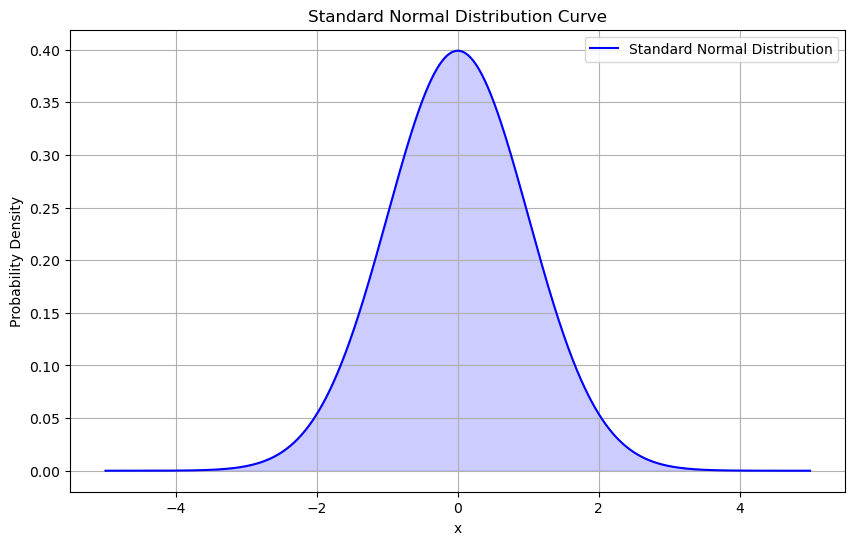

In [144]:
# Integrating the standard normal distribution curve from -inf to +inf
# Expected result: 1
def f_gauss(x):
    return np.exp(-x**2 / 2)/np.sqrt(2 * np.pi)
exact_sol_gauss = 1

plt.figure(figsize=(10, 6))
# Plot the standard normal distribution curve
x = np.linspace(-5, 5, 1000)
plt.plot(x, f_gauss(x), label='Standard Normal Distribution', color='blue')
# Fill the area under the curve from -inf to +inf
plt.fill_between(x, f_gauss(x), alpha=0.2, color='blue')
plt.title('Standard Normal Distribution Curve')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid()

In [145]:
res_gauss, err_gauss = integrate.quad(f_gauss, -np.inf, np.inf)
print(f"Result:          {res_gauss} +/- {err_gauss}")
print(f"Exact solution:  {exact_sol_gauss}")
print(f"Absolute error:  {abs(res_gauss - exact_sol_gauss)}")

Result:          0.9999999999999998 +/- 1.0178191320905743e-08
Exact solution:  1
Absolute error:  2.220446049250313e-16


#### Endpoint Singularities

If your function blows up to infinity exactly at one of the integration bounds, `quad` is usually smart enough to handle it without any extra help.

$$ \int_0^1 \frac{1}{\sqrt{x}} dx $$

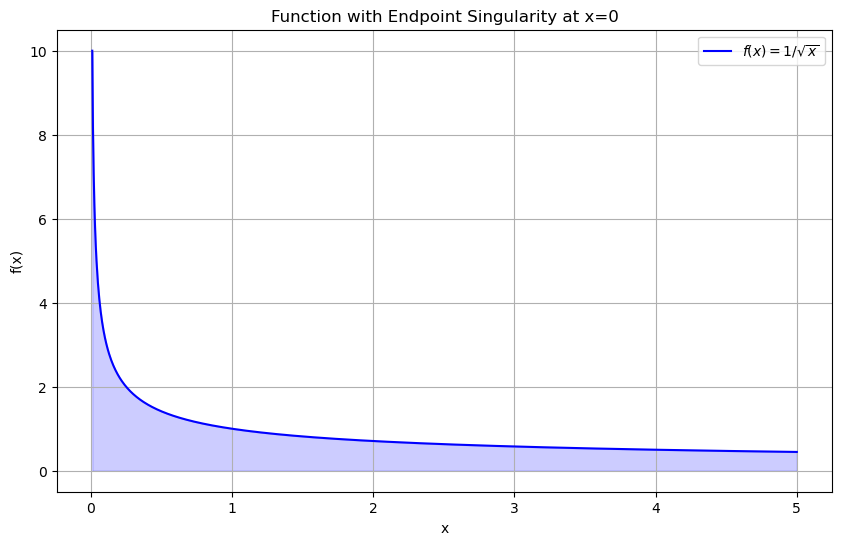

In [146]:
# The function approaches infinity as x -> 0
def f_end_singularity(x):
    return 1/np.sqrt(x)
exact_sol_singularity = 2  # The integral of 1/sqrt(x) from 0 to 1 is 2

plt.figure(figsize=(10, 6))
# Plot the function with a singularity at x=0
x = np.linspace(0.01, 5, 1000)  # Start from 0.01 to avoid division by zero
plt.plot(x, f_end_singularity(x), label=r'$f(x) = 1/\sqrt{x}$', color='blue')
plt.fill_between(x, f_end_singularity(x), alpha=0.2, color='blue')
plt.title('Function with Endpoint Singularity at x=0')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()

In [147]:
# quad handles the singularity at x=0 gracefully
res_end, err_end = integrate.quad(f_end_singularity, 0, 1)
print(f"\nEndpoint singularity result: {res_end} +/- {err_end}")
print(f"Exact solution:                {exact_sol_singularity}")


Endpoint singularity result: 1.9999999999999984 +/- 5.773159728050814e-15
Exact solution:                2


#### Interior Singularities (`points` argument)

If a singularity occurs **inside** the integration bounds, standard quadrature will often fail, miss the spike, or trigger a maximum subdivision warning. You must tell the algorithm exactly where the bad points are using the `points` argument.

$$ \int_{-1}^1 \frac{1}{\sqrt{|x|}} dx $$

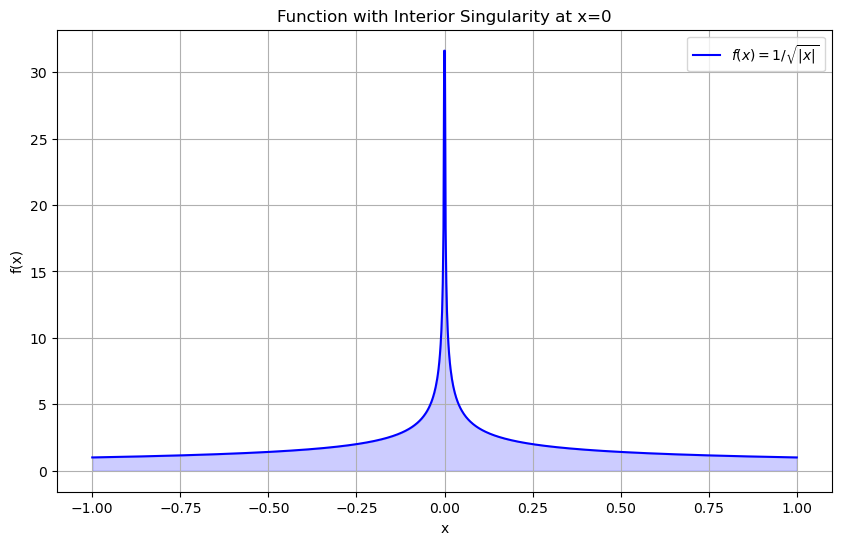

In [148]:
def f_interior_singularity(x):
    return 1 / np.sqrt(np.abs(x))
exact_sol_interior = 4  # The integral of 1/sqrt(|x|) from -1 to 1 is 4

plt.figure(figsize=(10, 6))
# Plot the function with a singularity at x=0
x = np.linspace(-1, 1, 1000)
plt.plot(x, f_interior_singularity(x), label=r'$f(x) = 1/\sqrt{|x|}$', color='blue')
plt.fill_between(x, f_interior_singularity(x), alpha=0.2, color='blue')
plt.title('Function with Interior Singularity at x=0')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()

In [149]:
'''
# BAD: The algorithm might struggle across x=0
res_bad, err_bad, info_bad, msg_bad = integrate.quad(
    f_interior_singularity, -1, 1, full_output=True
)
print(f"\nWithout 'points': Error = {err_bad} | Message: {msg_bad}")
'''

# GOOD: We explicitly warn quad about the singularity at x=0
res_good, err_good, info_good = integrate.quad(
    f_interior_singularity, -1, 1, points=[0], full_output=True
)
print(f"neval: {info_good['neval']}")
print(f"Correct Result:   {res_good} +/- {err_good}")
print(f"Exact solution:   {exact_sol_interior}")

neval: 462
Correct Result:   3.9999999999999813 +/- 5.684341886080802e-14
Exact solution:   4


### Weighted Integration with `weight` parameter

The `quad` function allows computing integrals with specific weight functions via the `weight` parameter. This is useful for Fourier integrals or singular integrals like Cauchy principal values.

Available weights include:
- `cos` or `sin`: $w(x) = \cos(\omega x)$ or $w(x) = \sin(\omega x)$
- `alg`: $w(x) = (x-a)^{\alpha}(b-x)^{\beta}$ (algebraic)
- `cauchy`: $w(x) = \frac{1}{x-c}$ (Cauchy principal value)

In [150]:
# Example: Using weight='sin' for Fourier integrals
# Computing integral of f(x) * sin(w * x) from 0 to 1
# Let's say f(x) = x and we want to calculate integral of x * sin(2*x) dx from 0 to 1

w = 2.0
def f(x):
    return x

# weight='sin' automatically calculates integral of f(x) * sin(w*x)
res_sin, err_sin = integrate.quad(f, 0, 1, weight='sin', wvar=w)
print(f"Fourier Integral (weight='sin'): {res_sin} +/- {err_sin}")

exact_sin = (np.sin(2)/4) - (np.cos(2)/2) # Analytic solution
print(f"Exact Solution:                  {exact_sin}")

Fourier Integral (weight='sin'): 0.4353977749799916 +/- 4.833886346533496e-15
Exact Solution:                  0.43539777497999166


In [151]:
# Example: Using weight='cauchy' for Cauchy principal value integral
# Integral of f(x)/(x-c) dx from -1 to 1, where c=0

def g(x):
    return 1.0 # f(x) = 1

# weight='cauchy' requires calculating Cauchy principal value at c
c = 0.0
res_cauchy, err_cauchy = integrate.quad(g, -1, 1, weight='cauchy', wvar=c)
print(f"Cauchy PV Integral (weight='cauchy'): {res_cauchy} +/- {err_cauchy}")
print("Exact Solution:                       0.0")

Cauchy PV Integral (weight='cauchy'): 2.220446049250313e-16 +/- 7.273495740812831e-13
Exact Solution:                       0.0


## Vectorized Integration: `scipy.integrate.quad_vec()`

Standard `quad()` expects a function that returns a single float. If your function returns an array (or if you want to integrate a vector-valued function), you should use `quad_vec()`. It is highly optimized for returning `numpy` arrays.

In [152]:
# Suppose we want to integrate a set of functions simultaneously:
# f_1(x) = x, f_2(x) = x^2, f_3(x) = x^3
def f_vec(x):
    # Returns a numpy array
    return np.array([x, x**2, x**3])

# Integrate all three functions from 0 to 1 at the same time
result_vec, error_vec = integrate.quad_vec(f_vec, 0, 1)

print("Vectorized Integration Results:")
print(f"Integral of [x, x^2, x^3] from 0 to 1: {result_vec}")
# Expected: [0.5, 0.333..., 0.25]

Vectorized Integration Results:
Integral of [x, x^2, x^3] from 0 to 1: [0.5        0.33333333 0.25      ]


## Double Integrals: `scipy.integrate.dblquad()`

`dblquad()` computes a double integral. The general mathematical form is:
$$ \int_a^b \int_{g(x)}^{h(x)} f(y, x) dy dx $$

**Crucial Note:** SciPy expects the callable function to be defined as `f(y, x)` where the first argument `y` corresponds to the inner integral, and the second argument `x` corresponds to the outer integral.

The bounds for the inner integral (`y`) can be functions of `x` (callables), while the bounds for the outer integral (`x`) must be constants.

In [153]:
# Example: Area of a circle with radius 1
# Equation: x^2 + y^2 <= 1  =>  y bounds: -sqrt(1-x^2) to sqrt(1-x^2)
#                           =>  x bounds: -1 to 1

# The function to integrate is just 1 (we are calculating area)
def f2(y, x):
    return 1

# Define the boundary functions for y
def bounds_y_lower(x):
    return -np.sqrt(1 - x**2)

def bounds_y_upper(x):
    return np.sqrt(1 - x**2)

# dblquad signature: func, x_lower, x_upper, y_lower_func, y_upper_func
area, err_area = integrate.dblquad(f2, -1, 1, bounds_y_lower, bounds_y_upper)

print(f"Calculated Area of circle: {area} +/- {err_area}")
print(f"Exact Area (Pi):           {np.pi}")

Calculated Area of circle: 3.1415926535897967 +/- 2.000470900043183e-09
Exact Area (Pi):           3.141592653589793


### 5. Triple Integrals: `scipy.integrate.tplquad()`

`tplquad()` takes this one step further for volume integrals:
$$ \int_a^b \int_{g(x)}^{h(x)} \int_{q(x,y)}^{r(x,y)} f(z, y, x) dz dy dx $$

Again, pay attention to the order of variables: `f(z, y, x)`. The innermost bounds (`z`) are functions of `x` and `y`.

In [154]:
# Example: Volume of a sphere with radius 1
# x bounds: -1 to 1
# y bounds: -sqrt(1-x^2) to sqrt(1-x^2)
# z bounds: -sqrt(1-x^2-y^2) to sqrt(1-x^2-y^2)

f3 = lambda z, y, x: 1

# y bounds (functions of x)
y_low  = lambda x: -np.sqrt(1 - x**2)
y_high = lambda x:  np.sqrt(1 - x**2)

# z bounds (functions of x and y)
z_low  = lambda x, y: -np.sqrt(1 - x**2 - y**2)
z_high = lambda x, y:  np.sqrt(1 - x**2 - y**2)

volume, err_vol = integrate.tplquad(f3, -1, 1, y_low, y_high, z_low, z_high)

print(f"Calculated Volume of sphere: {volume} +/- {err_vol}")
print(f"Exact Volume (4/3 * Pi):     {4/3 * np.pi}")

Calculated Volume of sphere: 4.188790204786397 +/- 2.000470900043183e-09
Exact Volume (4/3 * Pi):     4.1887902047863905


### 6. N-Dimensional Integrals: `scipy.integrate.nquad()`

For integrals beyond three dimensions, or for a cleaner syntax when dealing with many constant bounds, use `nquad()`.

Unlike `dblquad` and `tplquad` which require you to pass bounds as individual arguments and callables, `nquad` accepts a list of bounds.

In [155]:
# Let's calculate the expected value of a 4D probability distribution
# Integrating f(x1, x2, x3, x4) = x1 * x2 * x3 * x4 over [0, 1] for all variables

def f4(x1, x2, x3, x4):
    return x1 * x2 * x3 * x4

# Define the bounds. nquad expects a list of tuples for constant bounds:
# [(x1_min, x1_max), (x2_min, x2_max), ...]
bounds = [[0, 1], [0, 1], [0, 1], [0, 1]]

result_n, error_n = integrate.nquad(f4, bounds)

print(f"4D Integral result: {result_n} +/- {error_n}")
# Expected: (1/2)^4 = 1/16 = 0.0625

# Feature: nquad with dynamic bounds
# You can also pass a list of callables to 'ranges' if the bounds depend on outer variables.
# The signature for the callables depends on their position (inner bounds take outer variables).

4D Integral result: 0.06249999999999999 +/- 5.51503220577779e-15


### Passing Options to N-Dimensional Integrals

While `quad` and `dblquad` accept `epsabs` directly as keyword arguments, `nquad` manages its configuration differently. Because each dimension might need different settings (or specific singularity points), `nquad` uses the `opts` argument.

In [156]:
# Integrating a 2D function with strict tolerances using nquad
def f_2d(x, y):
    return np.sin(x) * np.cos(y)

# bounds for [x, y]
bounds = [[0, np.pi], [0, np.pi/2]]

# Pass options as a dictionary.
# If you pass a single dictionary, it applies to all dimensions.
# If you pass a list of dictionaries, they apply to each dimension respectively.
options = {'epsabs': 1e-10, 'epsrel': 1e-10}

res_nquad, err_nquad = integrate.nquad(f_2d, bounds, opts=options)

print(f"Exact result;                 {2.0}")
print(f"nquad with strict tolerances: {res_nquad} +/- {err_nquad}")

Exact result;                 2.0
nquad with strict tolerances: 1.9999999999999998 +/- 2.2204460492503128e-14
